# 02. Data Preprocessing & Feature Engineering

**Dataset:** NYC TLC Green Taxi trip records (2024–2026)  
**Target variable:** `tip_amount` — Regression problem  
**Scope:** credit-card trips only (payment_type == 1), since cash tips are not recorded

## Sections
0. Imports & Constants  
1. Load Raw Data  
2. Exploratory Data Analysis  
3. Data Cleaning  
4. Define Target Variable  
5. Feature Engineering  
6. Reference / Analysis Split  
7. Save to Hopsworks Feature Store  
8. Save Intermediate Files (for Kedro pipelines)

## 0. Imports & Constants

In [16]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature store
import hopsworks

# Paths (relative to notebooks/ folder)
RAW_DATA_PATH = "../data/01_raw/green_taxi"

# -----------------------------
# DATA SPLITS
# -----------------------------


# ML Training
TRAIN_YEARS = [2024, 2025]
VALIDATION_YEARS = [2025]


RANDOM_STATE = 42

# Target
TARGET_COL = "tip_amount"

# Hopsworks
FS_API_KEY = os.getenv("FS_API_KEY", "YOUR_API_KEY_HERE")
FS_PROJECT_NAME = os.getenv("FS_PROJECT_NAME", "mlops_novaims")

print("Imports OK")

Imports OK


## 1. Load Raw Data

We load all monthly parquet files and concatenate them. The folder structure is:
```
data/01_raw/green_taxi/{year}/green_tripdata_{year}-{month}.parquet
```

In [17]:
def load_parquet_folder(base_path: str, years: list) -> pd.DataFrame:
    """Load all monthly parquet files for the given years."""
    
    files = []

    for year in years:
        pattern = os.path.join(base_path, str(year), "*.parquet")
        files.extend(sorted(glob.glob(pattern)))

    print(f"Loading {len(files)} parquet files...")

    dfs = [pd.read_parquet(f) for f in files]
    df = pd.concat(dfs, ignore_index=True)

    print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")

    return df

In [18]:
ml_raw = load_parquet_folder(RAW_DATA_PATH, [2024, 2025])

Loading 24 parquet files...
Loaded 1,251,593 rows, 21 columns


In [19]:
ml_raw["lpep_pickup_datetime"] = pd.to_datetime(
    ml_raw["lpep_pickup_datetime"]
)

In [20]:
train_df = ml_raw[
    ml_raw["lpep_pickup_datetime"] < "2025-07-01"
].copy()

val_df = ml_raw[
    ml_raw["lpep_pickup_datetime"] >= "2025-07-01"
].copy()

In [21]:
print(f"Train rows      : {len(train_df):,}")
print(f"Validation rows : {len(val_df):,}")

print("\nTrain period:")
print(
    train_df["lpep_pickup_datetime"].min(),
    "->",
    train_df["lpep_pickup_datetime"].max()
)

print("\nValidation period:")
print(
    val_df["lpep_pickup_datetime"].min(),
    "->",
    val_df["lpep_pickup_datetime"].max()
)

Train rows      : 963,632
Validation rows : 287,961

Train period:
2008-12-31 00:00:00 -> 2025-06-30 23:54:44

Validation period:
2025-07-01 00:00:54 -> 2026-01-01 21:09:39


## 3. Data Cleaning and Preprocessing

Steps:
- Drop `ehail_fee` (100% null)
- Filter to credit-card trips only (`payment_type == 1`)
- Remove rows with invalid trip distances (≤ 0)
- Remove rows with negative fares
- Remove outliers (extreme distances / durations)
- Remove rows with no pickup/dropoff timestamps

In [ ]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Clean raw green taxi data."""
    n_start = len(df)
    
    # Drop fully null column
    df = df.drop(columns=['ehail_fee'], errors='ignore')
    
    # Filter to credit card trips only (cash tips not recorded)
    df = df[df['payment_type'] == 1].copy()
    print(f"After credit card filter: {len(df):,} ({len(df)/n_start*100:.1f}% of original)")
    
    # Drop rows missing essential fields
    df = df.dropna(subset=['lpep_pickup_datetime', 'lpep_dropoff_datetime',
                            'PULocationID', 'DOLocationID', 'trip_distance', 'fare_amount'])
    
    # Filter valid trip distances (> 0 and < 100 miles)
    df = df[(df['trip_distance'] > 0) & (df['trip_distance'] < 100)]
    
    # Filter valid fares (> 0 and < 500)
    df = df[(df['fare_amount'] > 0) & (df['fare_amount'] < 500)]
    
    # Filter valid timestamps (no future dates, no dates before 2024)
    df = df[df['lpep_pickup_datetime'] >= '2024-01-01']
    df = df[df['lpep_dropoff_datetime'] > df['lpep_pickup_datetime']]
    
    # Compute duration for outlier removal
    duration_min = (df['lpep_dropoff_datetime'] - df['lpep_pickup_datetime']).dt.total_seconds() / 60
    # Keep trips between 1 and 180 minutes
    df = df[(duration_min >= 1) & (duration_min <= 180)]

    #Clean target column
    df = df.dropna(subset=["tip_amount"])
    df = df[df["tip_amount"] >= 0]
    df = df[df["tip_amount"] < 200]

    #Drop duplicates
    df = df.drop_duplicates()

    #Drop small number of missing values
    df = df.dropna(subset=["trip_type"])

    #Remove cbd_congestion_fee as it doesn't add information and has a lot of missing data
    df = df.drop(columns=["cbd_congestion_fee"], errors="ignore")
    
    print(f"After cleaning: {len(df):,} rows remaining")
    return df.reset_index(drop=True)


train_clean = clean_data(train_df)
print()
val_clean = clean_data(val_df)

After credit card filter: 668,297 (69.4% of original)
After cleaning: 622,310 rows remaining

After credit card filter: 193,002 (67.0% of original)
After cleaning: 184,627 rows remaining


## 4. Define Target Variable

The target is going to be **`tip_amount`**

## 5. Feature Engineering

New features derived from raw columns:

| Feature | Description | Source |
|---|---|---|
| `trip_duration_min` | Trip duration in minutes | pickup/dropoff datetime |
| `pickup_hour` | Hour of pickup (0–23) | lpep_pickup_datetime |
| `pickup_dayofweek` | Day of week (0=Mon, 6=Sun) | lpep_pickup_datetime |
| `pickup_month` | Month (1–12) | lpep_pickup_datetime |
| `is_weekend` | 1 if Saturday or Sunday | pickup_dayofweek |
| `is_rush_hour` | 1 if weekday 7–9am or 5–7pm | pickup_hour + is_weekend |
| `is_night` | 1 if pickup between 10pm–5am | pickup_hour |
| `speed_mph` | Average trip speed (miles/hour) | distance + duration |
| `fare_per_mile` | Fare divided by distance | fare_amount + trip_distance |
| `is_airport` | 1 if PU or DO at JFK/LGA/EWR | PULocationID / DOLocationID |
| `PU_borough` | Borough of pickup zone | zone lookup |
| `DO_borough` | Borough of dropoff zone | zone lookup |

In [35]:
# NYC airport zone IDs (JFK=132, LGA=138, EWR=1)
AIRPORT_ZONE_IDS = {1, 132, 138}

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Engineer features from raw green taxi trip data."""
    df = df.copy()
    
    # --- Temporal features ---
    pickup = pd.to_datetime(df['lpep_pickup_datetime'])
    dropoff = pd.to_datetime(df['lpep_dropoff_datetime'])
    
    df['trip_duration_min'] = (dropoff - pickup).dt.total_seconds() / 60
    df['pickup_hour']       = pickup.dt.hour
    df['pickup_dayofweek']  = pickup.dt.dayofweek  # 0=Monday, 6=Sunday
    df['pickup_month']      = pickup.dt.month
    
    df['is_weekend']   = (df['pickup_dayofweek'] >= 5).astype(int)
    df['is_rush_hour'] = (
        (df['is_weekend'] == 0) &
        (df['pickup_hour'].isin(range(7, 10)) | df['pickup_hour'].isin(range(17, 20)))
    ).astype(int)
    df['is_night'] = (df['pickup_hour'].isin(list(range(22, 24)) + list(range(0, 6)))).astype(int)
    
    
    # --- Location features ---
    df['is_airport'] = (
        df['PULocationID'].isin(AIRPORT_ZONE_IDS) |
        df['DOLocationID'].isin(AIRPORT_ZONE_IDS)
    ).astype(int)
    
    
    return df


train_feat = engineer_features(train_clean)
val_feat = engineer_features(val_clean)

print("Train features shape:", train_feat.shape)
print("Val features shape: ", val_feat.shape)

Train features shape: (622310, 27)
Val features shape:  (184627, 27)


In [37]:
# Preview engineered features
new_cols = ['trip_duration_min', 'pickup_hour', 'pickup_dayofweek', 'pickup_month',
            'is_weekend', 'is_rush_hour', 'is_night','is_airport']
train_feat[new_cols].head()

,trip_duration_min,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,is_rush_hour,is_night,is_airport
0,11.500000,0,0,1,0,0,1,0
1,20.866667,0,0,1,0,0,1,0
2,19.033333,0,0,1,0,0,1,0
3,10.983333,0,0,1,0,0,1,0
4,16.700000,0,0,1,0,0,1,0


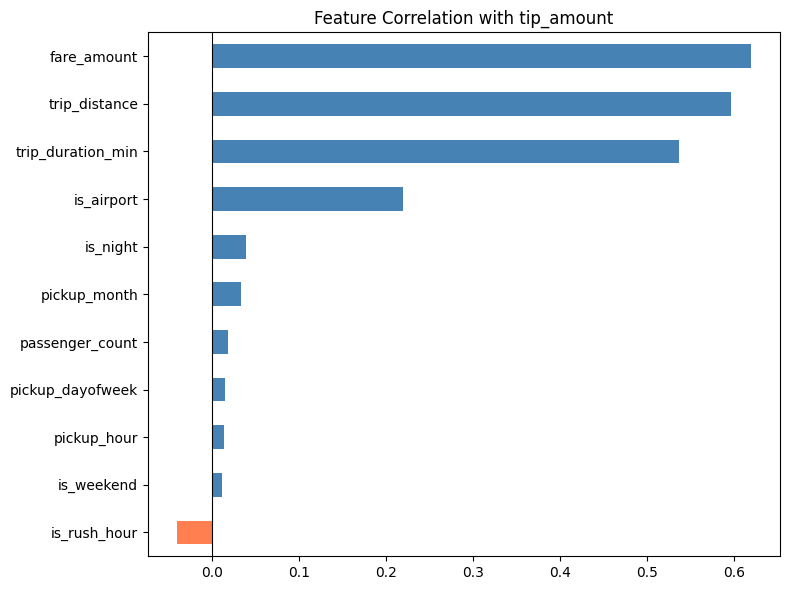

In [46]:
# Correlation of engineered features with target
numeric_cols = ['trip_duration_min', 'pickup_hour', 'pickup_dayofweek', 'pickup_month',
                'is_weekend', 'is_rush_hour', 'is_night',
                 'is_airport',"tip_amount",
                'trip_distance', 'fare_amount', 'passenger_count',]

corr = train_feat[numeric_cols].corr()['tip_amount'].drop('tip_amount').sort_values()

plt.figure(figsize=(8, 6))
corr.plot(kind='barh', color=['coral' if v < 0 else 'steelblue' for v in corr])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with tip_amount')
plt.tight_layout()
plt.show()

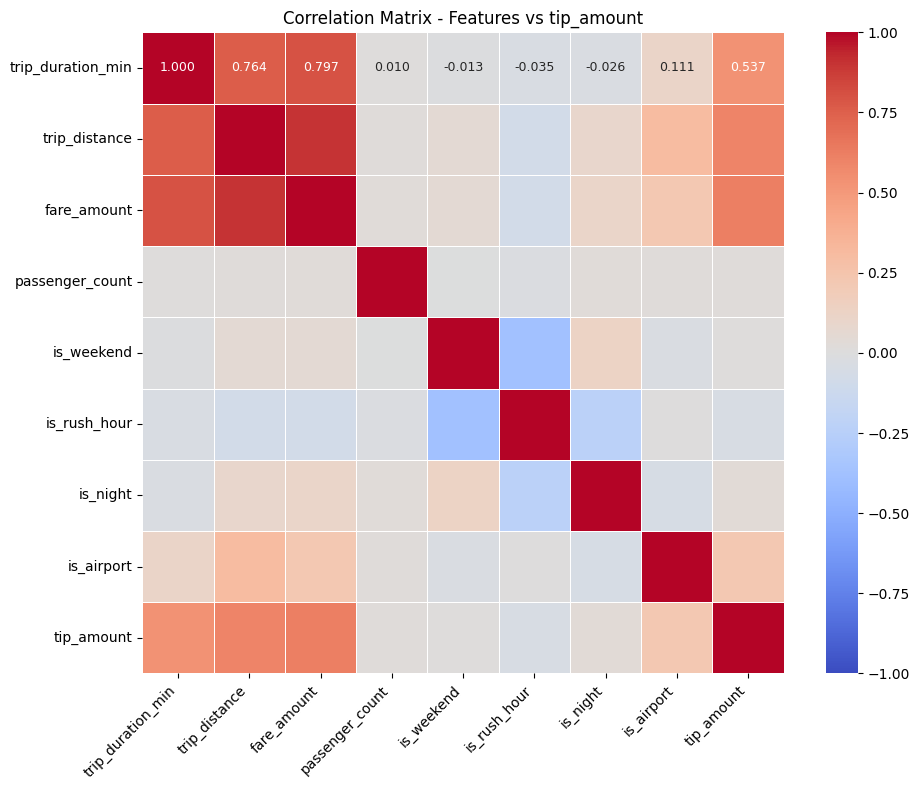

In [49]:
numeric_cols = [
    'trip_duration_min', 'trip_distance', 'fare_amount', 'passenger_count',
    'is_weekend', 'is_rush_hour', 'is_night', 'is_airport', 'tip_amount'
]

corr_matrix = train_feat[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={"size": 9})
plt.title('Correlation Matrix - Features vs tip_amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Select Final Feature Set

Drop columns that are:
- **Leakage**:  `total_amount` (contain or derive the target)
- **Raw temporal**: `lpep_pickup_datetime`, `lpep_dropoff_datetime` (replaced by engineered features)
- **Redundant**: `payment_type` (we filtered to credit card only, all == 1)
- **Administrative**: `store_and_fwd_flag`, `VendorID`

In [51]:
COLS_TO_DROP = [
    'total_amount',          # leakage (includes tip)
    'lpep_pickup_datetime',  # replaced by engineered features
    'lpep_dropoff_datetime', # replaced by engineered features
    'payment_type',          # constant after filtering (all == 1)
    'store_and_fwd_flag',    # administrative
    'VendorID',              # administrative
]

def select_features(df: pd.DataFrame) -> pd.DataFrame:
    cols_to_drop = [c for c in COLS_TO_DROP if c in df.columns]
    return df.drop(columns=cols_to_drop)

train_final = select_features(train_feat)
val_final = select_features(val_feat)

print("Final feature columns:")
print(train_final.columns.tolist())
print(f"\nReference shape: {train_final.shape}")
print(f"Analysis shape:  {val_final.shape}")

Final feature columns:
['RatecodeID', 'PULocationID', 'DOLocationID', 'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'trip_type', 'congestion_surcharge', 'trip_duration_min', 'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'is_weekend', 'is_rush_hour', 'is_night', 'is_airport']

Reference shape: (622310, 21)
Analysis shape:  (184627, 21)


In [53]:
# Final null check
print("Nulls in reference features:")
print(train_final.isnull().sum()[train_final.isnull().sum() > 0])

print("\nNull check after fill: OK" if train_final.isnull().sum().sum() == 0 else "Still has nulls!")

Nulls in reference features:
Series([], dtype: int64)

Null check after fill: OK


In [54]:
train_final

,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,...,trip_type,congestion_surcharge,trip_duration_min,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,is_rush_hour,is_night,is_airport
0,1.0,236,239,1.0,1.98,12.8,1.00,0.5,3.61,0.0,...,1.0,2.75,11.500000,0,0,1,0,0,1,0
1,1.0,65,170,5.0,6.54,30.3,1.00,0.5,7.11,0.0,...,1.0,2.75,20.866667,0,0,1,0,0,1,0
2,1.0,74,262,1.0,3.08,19.8,1.00,0.5,3.00,0.0,...,1.0,2.75,19.033333,0,0,1,0,0,1,0
3,1.0,74,243,1.0,5.14,22.6,1.00,0.5,6.28,0.0,...,1.0,0.00,10.983333,0,0,1,0,0,1,0
4,1.0,33,209,1.0,2.00,17.0,3.75,1.5,2.00,0.0,...,1.0,2.75,16.700000,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
622305,1.0,95,102,1.0,1.42,9.3,1.00,0.5,2.95,0.0,...,1.0,0.00,8.066667,23,0,6,0,0,1,0
622306,1.0,129,134,1.0,4.58,26.1,1.00,0.5,5.00,0.0,...,1.0,0.00,24.500000,22,0,6,0,0,1,0
622307,1.0,82,129,1.0,1.31,9.3,1.00,0.5,3.54,0.0,...,1.0,0.00,7.700000,23,0,6,0,0,1,0
622308,1.0,93,255,1.0,8.75,36.6,0.00,0.5,7.62,0.0,...,1.0,0.00,23.100000,21,1,6,0,0,0,0


In [55]:
val_final

,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,...,trip_type,congestion_surcharge,trip_duration_min,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,is_rush_hour,is_night,is_airport
0,1.0,130,135,1.0,3.24,17.7,0.0,0.5,3.84,0.0,...,1.0,0.00,13.683333,7,1,7,0,1,0,0
1,1.0,42,42,1.0,0.56,5.8,0.0,0.5,1.46,0.0,...,1.0,0.00,3.516667,14,1,7,0,0,0,0
2,1.0,130,130,1.0,13.08,62.5,2.5,0.5,13.30,0.0,...,1.0,0.00,58.283333,17,1,7,0,1,0,0
3,1.0,130,61,1.0,8.93,41.5,1.0,0.5,0.00,0.0,...,1.0,0.00,36.000000,20,1,7,0,0,0,0
4,1.0,66,162,1.0,6.47,26.8,1.0,0.5,0.00,0.0,...,1.0,2.75,14.516667,0,1,7,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184622,1.0,74,43,1.0,1.50,10.0,1.0,0.5,1.00,0.0,...,1.0,0.00,7.900000,23,2,12,0,0,1,0
184623,1.0,43,236,1.0,1.19,7.2,1.0,0.5,1.87,0.0,...,1.0,2.75,4.250000,23,2,12,0,0,1,0
184624,1.0,75,74,1.0,1.33,7.9,1.0,0.5,2.08,0.0,...,1.0,0.00,4.000000,23,2,12,0,0,1,0
184625,1.0,74,75,1.0,1.30,7.9,1.0,0.5,0.00,0.0,...,1.0,0.00,4.900000,23,2,12,0,0,1,0


## 7. Save to Hopsworks Feature Store

We create two feature groups:
- **`green_taxi_ref_features`** — reference (training) data from 2024
- **`green_taxi_ana_features`** — analysis (batch/drift) data from 2025–2026

Set `to_feature_store = True` to actually upload. Leave `False` during development.

In [ ]:
TO_FEATURE_STORE = False  # Set to True to upload

if TO_FEATURE_STORE:
    project = hopsworks.login(
        api_key_value=FS_API_KEY,
        project=FS_PROJECT_NAME
    )
    fs = project.get_feature_store()
    print(f"Connected to project: {FS_PROJECT_NAME}")

In [ ]:
def upload_feature_group(
    fs,
    df: pd.DataFrame,
    group_name: str,
    version: int = 1,
    description: str = ""
):
    """Create or get a feature group and upload data."""
    fg = fs.get_or_create_feature_group(
        name=group_name,
        version=version,
        description=description,
        primary_key=['index'],
        online_enabled=False,
    )
    df_upload = df.reset_index().rename(columns={'index': 'index'})
    fg.insert(df_upload, overwrite=False, write_options={"wait_for_job": True})
    fg.compute_statistics()
    print(f"Uploaded {len(df):,} rows to feature group '{group_name}'")
    return fg


if TO_FEATURE_STORE:
    fg_ref = upload_feature_group(
        fs, ref_final,
        group_name="green_taxi_ref_features",
        description="Green Taxi 2024 reference features for training"
    )
    fg_ana = upload_feature_group(
        fs, ana_final,
        group_name="green_taxi_ana_features",
        description="Green Taxi 2025-2026 analysis features for batch inference and drift"
    )
else:
    print("Feature store upload skipped (TO_FEATURE_STORE=False). Set to True to upload.")

## 8. Save Intermediate Files (for Kedro pipelines)

Save the engineered datasets to `data/02_intermediate/` so the Kedro `ingestion` and `split_data` pipelines can pick them up.

In [ ]:
os.makedirs(INTERMEDIATE_PATH, exist_ok=True)

ref_out_path = os.path.join(INTERMEDIATE_PATH, "ref_data.parquet")
ana_out_path = os.path.join(INTERMEDIATE_PATH, "ana_data.parquet")

ref_final.to_parquet(ref_out_path, index=False)
ana_final.to_parquet(ana_out_path, index=False)

print(f"Saved reference data:  {ref_out_path} ({len(ref_final):,} rows)")
print(f"Saved analysis data:   {ana_out_path} ({len(ana_final):,} rows)")

In [ ]:
# Summary
print("=" * 50)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 50)
print(f"Reference (train) rows : {len(ref_final):,}")
print(f"Analysis (batch) rows  : {len(ana_final):,}")
print(f"Number of features     : {len(ref_final.columns) - 1}")
print(f"Target column          : {TARGET_COL}")
print(f"Target balance (ref)   : {ref_final[TARGET_COL].mean():.1%} tipped")
print()
print("Feature columns:")
feature_cols = [c for c in ref_final.columns if c != TARGET_COL]
for c in feature_cols:
    print(f"  - {c}")